In [123]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

from cluster_functions import *
palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

In [47]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')

In [56]:
def realiza_loop(log_m1, log_m2,min_mass, max_mass, dm=0.05):
        
        m_min = min_mass
        m_max = m_min+dm
        
        mass_bins = []
        P_prim_arr = []
        P_comp_arr = []
        P_BS_arr = []         
        
        while m_min <= max_mass:
            
            if m_max> max_mass:
                break
                
            if m_min < np.log10(4):
                dm = 0.05
            else:
                dm = np.log10(1 + 1 / (10**m_min))
                
            mask_m1 = (log_m1 >=m_min) & (log_m1 <m_max)
            mask_m2 = (log_m2 >=m_min) & (log_m2 < m_max)
            
            total_stars = mask_m1.sum() + mask_m2.sum()
                
            
            if total_stars>=100:
                P_prim, P_comp, P_BS, N_prim, N_comp, N_BS = get_probabilities(log_m2, mask_m1, mask_m2)
                
                masses = np.concatenate([log_m1[mask_m1], log_m2[mask_m2]]) 
                mass_bins.append(np.median(masses)) 
                P_prim_arr.append(P_prim) 
                P_comp_arr.append(P_comp) 
                P_BS_arr.append(P_BS)

                m_min = m_min + dm 
            m_max = m_max + dm

        return (np.array(mass_bins),np.array(P_prim_arr),np.array(P_comp_arr),np.array(P_BS_arr))

    

In [120]:
m1 = data['mass'].values
m2 = data['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = realiza_loop(log_m1, log_m2, min_mass, max_mass, dm=0.05)

#new_masses = np.load('new_masses.npy')
#new_comp_masses = np.load('new_comp_masses.npy')

dP_prim_arr, dP_comp_arr, dP_BS_arr = [], [], []
for i in range(0,len(new_masses)):
    new_comp_masses[i][q ==0] = 0
    
    log_m1 = np.log10(new_masses[i])
    log_m2 = np.log10(new_comp_masses[i])
    mb, dP_prim, dP_comp, dP_BS = realiza_loop(log_m1, log_m2, min_mass, max_mass, dm=0.05)
    dP_prim = np.interp(mass_bins, mb, dP_prim, left=np.nan, right=np.nan)
    dP_comp = np.interp(mass_bins, mb, dP_comp, left=np.nan, right=np.nan)
    dP_BS = np.interp(mass_bins, mb, dP_BS, left=np.nan, right=np.nan)

    dP_prim_arr.append(dP_prim)
    dP_comp_arr.append(dP_comp)
    dP_BS_arr.append(dP_BS)


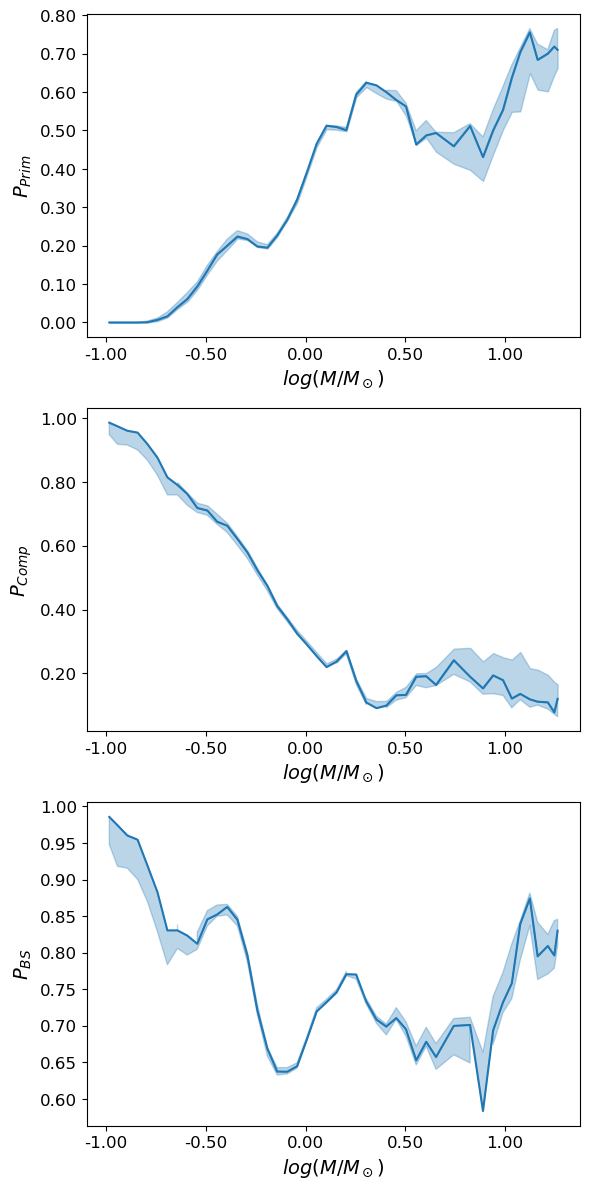

In [126]:
nominal_values = [P_prim, P_comp, P_BS]
standard_devs = [dP_prim_arr, dP_comp_arr, dP_BS_arr]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']

fig, axs = plt.subplots(3,1, figsize=(6,12))

for i in range(0, len(nominal_values)):
    axs[i].plot(mass_bins,  nominal_values[i],)
    axs[i].set_ylabel(labels[i], fontdict=font)
    
    minimos = [min(col) for col in zip(*standard_devs[i])]
    maximos = [max(col) for col in zip(*standard_devs[i])]
    axs[i].fill_between(mass_bins, nominal_values[i], maximos, alpha=0.3, color='tab:blue', where = maximos>=nominal_values[i])
    axs[i].fill_between(mass_bins, minimos, nominal_values[i], alpha=0.3, color='tab:blue', where = minimos<=nominal_values[i])
    axs[i].tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
    axs[i].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axs[i].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axs[i].set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.tight_layout()
plt.savefig('Figures/dist_fb_por_massa.png', dpi=300)
plt.show()



In [127]:
def realiza_loop_q(log_m1, q, min_mass, max_mass, dm=0.05):
        
        m_min = min_mass
        m_max = m_min+dm
        
        mass_bins = []
        qs = []
        
        while m_min <= max_mass:
            
            if m_max> max_mass:
                break
                
            if m_min < np.log10(4):
                dm = 0.05
            else:
                dm = np.log10(1 + 1 / (10**m_min))
                
            mask_m1 = (log_m1 >=m_min) & (log_m1 <m_max)            
            total_stars = mask_m1.sum()
            
            if total_stars>=100:               

                mass_bins.append(np.median(log_m1[mask_m1])) 
                qs.append(q[mask_m1].mean())
                m_min = m_min + dm 
            m_max = m_max + dm

        return (np.array(mass_bins),np.array(qs))

    

In [128]:

q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = realiza_loop_q(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

dq_arr = []
for i in range(0,len(new_masses)):
    
    log_m1_bin = np.log10(new_masses[i][q>0])
    q_ = new_comp_masses[i][q>0]/new_masses[i][q>0]

    min_mass = log_m1_bin.min()
    max_mass = log_m1_bin.max()
    
    mb, dq = realiza_loop_q(log_m1_bin, q_, min_mass, max_mass, dm=0.05)
    dq = np.interp(mass_bins, mb, dq, left=np.nan, right=np.nan)

    dq_arr.append(dq)


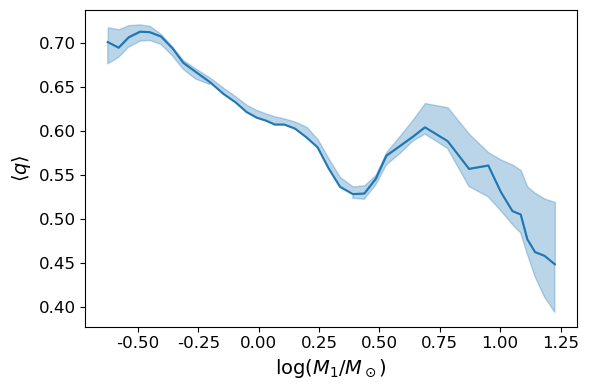

In [129]:
minimos = [min(col) for col in zip(*dq_arr)]
maximos = [max(col) for col in zip(*dq_arr)]

fig, axs = plt.subplots(figsize=(6,4))


axs.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
axs.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)
axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 
